## **Project Evaluation Metrics**

In [1]:
import requests
import json
import re
import pandas as pd
from dataclasses import dataclass
from typing import Optional

In [2]:
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL = "llama3:latest" 

#### **System Prompt inspired by Stanford's GREEN Evaluation Paper**

In [3]:
SYSTEM_PROMPT = """You are a radiologist evaluating an AI-generated radiology report.

Given a REFERENCE report (ground truth) and a CANDIDATE report (AI-generated), 
identify errors in the candidate by comparing it against the reference.

Classify each error as:
- SIGNIFICANT: clinically meaningful errors (wrong finding, missed finding, 
  wrong location, wrong severity, hallucinated pathology)
- INSIGNIFICANT: minor errors (wording differences, style, non-clinical phrasing)

Also count MATCHED FINDINGS: findings correctly present in both reports.

You MUST respond in this exact format and nothing else:

MATCHED_FINDINGS: <integer>
SIGNIFICANT_ERRORS: <integer>
INSIGNIFICANT_ERRORS: <integer>
SIGNIFICANT_ERROR_LIST:
- <description of error or "None">
INSIGNIFICANT_ERROR_LIST:
- <description of error or "None">
SUMMARY: <2-3 sentence overall assessment>
"""

In [4]:
@dataclass
class GREENResult:
    matched_findings: int
    significant_errors: int
    insignificant_errors: int
    significant_error_list: list[str]
    insignificant_error_list: list[str]
    summary: str
    green_score: float          # 0-1, higher is better
    hallucination_score: float  # 0-1, higher means more hallucinations
    raw_output: str

### **Helper Functions**

In [5]:
def parse_output(text: str) -> dict:
    """Extract structured fields from LLM output."""

    def extract_int(pattern, default=0):
        m = re.search(pattern, text, re.IGNORECASE)
        return int(m.group(1)) if m else default

    def extract_list(section_name):
        # grab everything between this section header and the next
        pattern = rf"{section_name}:\s*\n((?:\s*-[^\n]+\n?)*)"
        m = re.search(pattern, text, re.IGNORECASE)
        if not m:
            return []
        items = re.findall(r"-\s*(.+)", m.group(1))
        return [i.strip() for i in items if i.strip().lower() != "none"]

    def extract_summary():
        m = re.search(r"SUMMARY:\s*(.+?)(?:\n[A-Z_]+:|$)", text, re.IGNORECASE | re.DOTALL)
        return m.group(1).strip() if m else ""

    matched = extract_int(r"MATCHED_FINDINGS:\s*(\d+)")
    sig = extract_int(r"SIGNIFICANT_ERRORS:\s*(\d+)")
    insig = extract_int(r"INSIGNIFICANT_ERRORS:\s*(\d+)")

    return {
        "matched_findings": matched,
        "significant_errors": sig,
        "insignificant_errors": insig,
        "significant_error_list": extract_list("SIGNIFICANT_ERROR_LIST"),
        "insignificant_error_list": extract_list("INSIGNIFICANT_ERROR_LIST"),
        "summary": extract_summary(),
    }

In [6]:
def compute_scores(matched, sig_errors, insig_errors):
    total = matched + sig_errors + insig_errors
    green_score = matched / total if total > 0 else 1.0

    # hallucination: significant errors as fraction of all candidate content
    candidate_total = matched + sig_errors
    hallucination = sig_errors / candidate_total if candidate_total > 0 else 0.0

    return round(green_score, 4), round(hallucination, 4)

In [7]:
def score_report(reference: str, candidate: str) -> GREENResult:
    prompt = f"REFERENCE REPORT:\n{reference}\n\nCANDIDATE REPORT:\n{candidate}"

    response = requests.post(OLLAMA_URL, json={
        "model": MODEL,
        "system": SYSTEM_PROMPT,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0,
            "seed": 42,
            "num_predict": 512,
        }
    })
    response.raise_for_status()
    raw = response.json()["response"]

    parsed = parse_output(raw)
    green_score, hallucination = compute_scores(
        parsed["matched_findings"],
        parsed["significant_errors"],
        parsed["insignificant_errors"],
    )

    return GREENResult(
        **parsed,
        green_score=green_score,
        hallucination_score=hallucination,
        raw_output=raw,
    )


In [8]:
def evaluate_sample(true_report: str, pred_report: str) -> dict:
    result = score_report(true_report, pred_report)
    return {
        "green_score": result.green_score,
        "hallucination_score": result.hallucination_score,
        "matched_findings": result.matched_findings,
        "significant_errors": result.significant_errors,
        "insignificant_errors": result.insignificant_errors,
        "summary": result.summary,
        "sig_error_list": "; ".join(result.significant_error_list),
    }

In [9]:
from pathlib import Path

def load_reports(ref_dir, target_dir):
    with open(ref_dir, 'r') as file:
        reference_report = file.read()

    with open(target_dir, 'r') as file:
        target_report = file.read()
    
    return reference_report, target_report

In [10]:
import os
from tqdm import tqdm

def evaluate_reports(ref_dir:str, target_dir:str):
    target_reports_dir = os.listdir(target_dir)
    rows = []
    for i, _ in tqdm(enumerate(target_reports_dir)):
        ref_report_dirs = os.listdir(ref_dir)
        ref_report, target_report = load_reports(
            f"{ref_dir}/{ref_report_dirs[i]}",
            f"{target_dir}/{target_reports_dir[i]}"
        )

        results = evaluate_sample(ref_report, target_report)
        rows.append(results)
    
    return rows


In [53]:
ABLATIONS_DIR = "./outputs/ablations/reports_generation/"
IMP_DIR = "./outputs/reports_generation"
IMP_MODELS = ['deepseekr1', 'llama3', 'meditronv3']
BASELINE_DIR = "./outputs/baseline/reports/"
BASELINE_MASKS = ['pred_masks', 'true_masks']
IMP_MASKS = ['predicted_masks', 'true_masks']
BASELINE_MODELS = ['llava-13b', 'medgemma-27b', 'qwen-7b']
PAYLOAD_DIR = "./outputs/feature_extraction"

### **Dice Score Analysis of Segmentation Model**

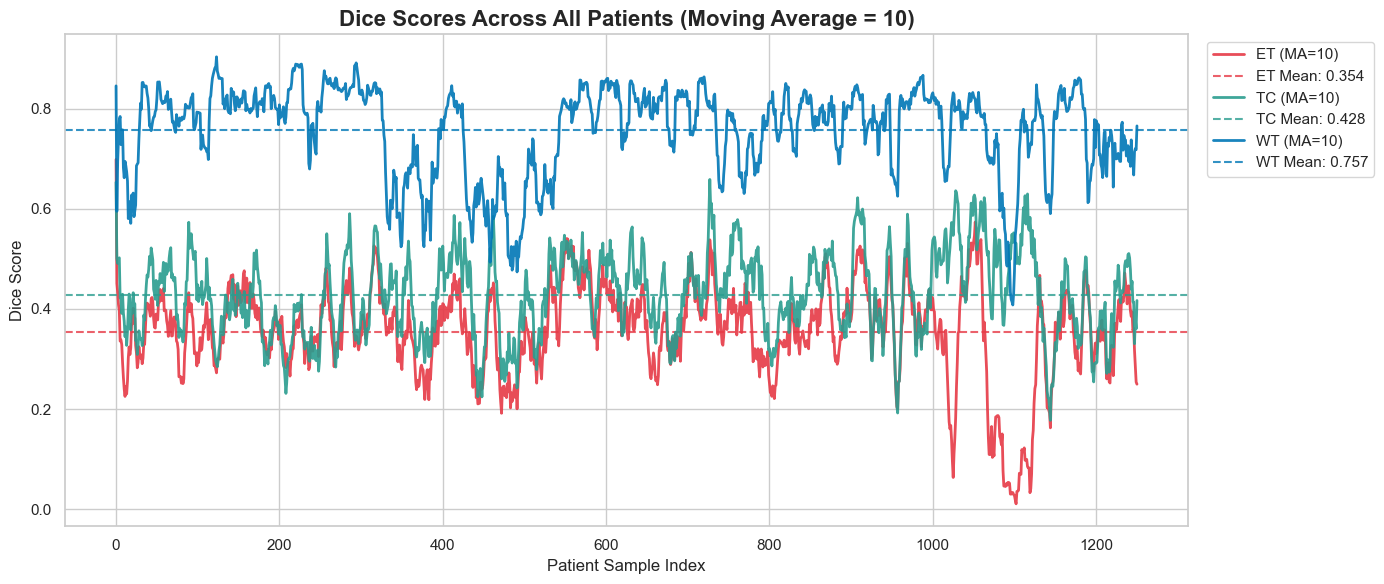

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

with open("./outputs/evaluation/dice_scores.json", 'r') as file:
    dice_scores = json.load(file)

df_dice = pd.DataFrame(dice_scores)
sns.set_theme(style="whitegrid")

dice_window = 10 

plt.figure(figsize=(14, 6))
colors = ['#e63946', '#2a9d8f', '#0077b6']

for i, channel in enumerate(df_dice.columns):
    ma = df_dice[channel].rolling(window=dice_window, min_periods=1).mean()
    mean_val = df_dice[channel].mean()
    
    plt.plot(ma, label=f'{channel} (MA={dice_window})', color=colors[i], linewidth=2, alpha=0.9)
    plt.axhline(mean_val, color=colors[i], linestyle='--', alpha=0.8, 
                label=f'{channel} Mean: {mean_val:.3f}')

plt.title(f'Dice Scores Across All Patients (Moving Average = {dice_window})', fontsize=16, fontweight='bold')
plt.xlabel('Patient Sample Index', fontsize=12)
plt.ylabel('Dice Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"./outputs/evaluation/dice_scores.png")
plt.show()

### **Evaluating the improvement models**

In [12]:
import json
import re
import logging
from pathlib import Path
from typing import Union
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

logger = logging.getLogger(__name__)


class ConsistencyScorer:
    _ENTAILMENT_IDX = 2 

    def __init__(self, model_name: str = "cross-encoder/nli-deberta-v3-base", aggregation: str = "mean", batch_size: int = 16, max_source_chunks: int = 5, device: str | None = None):
        self.aggregation = aggregation
        self.batch_size = batch_size
        self.max_source_chunks = max_source_chunks
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        logger.info(f"Loading {model_name} on {self.device}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
        self.model.to(self.device)
        self.model.eval()

    def score(self, reports_dir, payloads_dir):
    
        report_files = self._sorted_files(f"{reports_dir}", suffix=".txt")
        payload_files = self._sorted_files(payloads_dir, suffix=".json")


        paired = list(zip(report_files, payload_files[: len(report_files)]))
        scores = []

        for report_path, payload_path in tqdm(paired, desc="Scoring consistency"):
            report_text = report_path.read_text(encoding="utf-8")
            payload_text = self._flatten_json(json.loads(payload_path.read_text(encoding="utf-8")))
            scores.append(self._score_pair(report_text, payload_text))

        return scores

    def _score_pair(self, report: str, payload: str) -> float:
        claims = self._sentence_split(report)
        claims = [c for c in claims if len(c.split()) >= 3]
        if not claims:
            return 0.0

        chunks = self._chunk(payload)
        if not chunks:
            return 0.0

        claim_scores = [self._max_entailment(c, chunks) for c in claims]
        return self._aggregate(claim_scores)

    def _max_entailment(self, claim: str, chunks: list[str]) -> float:
        """Max entailment probability of a claim across source chunks."""
        chunks = chunks[: self.max_source_chunks]
        probs = self._nli(premises=chunks, hypotheses=[claim] * len(chunks))
        return max(probs)

    def _nli(self, premises: list[str], hypotheses: list[str]) -> list[float]:
        """Run NLI and return entailment probability for each pair."""
        results = []
        for i in range(0, len(premises), self.batch_size):
            enc = self.tokenizer(
                premises[i : i + self.batch_size],
                hypotheses[i : i + self.batch_size],
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt",
            ).to(self.device)
            with torch.no_grad():
                logits = self.model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[:, self._ENTAILMENT_IDX]
            results.extend(probs.cpu().tolist())
        return results

    def _aggregate(self, scores: list[float]) -> float:
        if self.aggregation == "mean":
            return sum(scores) / len(scores)
        elif self.aggregation == "median":
            s = sorted(scores)
            m = len(s) // 2
            return (s[m - 1] + s[m]) / 2 if len(s) % 2 == 0 else s[m]
        elif self.aggregation == "min":
            return min(scores)
        raise ValueError(f"Unknown aggregation: {self.aggregation}")

    @staticmethod
    def _sentence_split(text: str) -> list[str]:
        try:
            import nltk
            try:
                return nltk.sent_tokenize(text)
            except LookupError:
                nltk.download("punkt", quiet=True)
                nltk.download("punkt_tab", quiet=True)
                return nltk.sent_tokenize(text)
        except ImportError:
            return [
                s.strip()
                for s in re.split(r"(?<=[.!?])\s+(?=[A-Z])", text.strip())
                if s.strip()
            ]

    @staticmethod
    def _chunk(text: str, max_words: int = 300, overlap: int = 50) -> list[str]:
        words = text.split()
        if not words:
            return []
        step = max(1, max_words - overlap)
        chunks = []
        for start in range(0, len(words), step):
            chunks.append(" ".join(words[start : start + max_words]))
            if start + max_words >= len(words):
                break
        return chunks

    @staticmethod
    def _flatten_json(obj) -> str:
        """Recursively extract all values from a JSON object into a single string."""
        parts = []
        if isinstance(obj, dict):
            for v in obj.values():
                parts.append(ConsistencyScorer._flatten_json(v))
        elif isinstance(obj, list):
            for item in obj:
                parts.append(ConsistencyScorer._flatten_json(item))
        elif obj is not None:
            parts.append(str(obj))
        return " ".join(p for p in parts if p.strip())

    @staticmethod
    def _sorted_files(directory: Union[str, Path], suffix: str) -> list[Path]:
        def natural_key(p):
            return [
                int(x) if x.isdigit() else x.lower()
                for x in re.split(r"(\d+)", p.stem)
            ]
        return sorted(
            [f for f in Path(directory).iterdir() if f.suffix.lower() == suffix],
            key=natural_key,
        )

c:\Users\Syed Daniyal\.conda\envs\cs437_proj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### **With Knowledge Graph**

In [71]:
evaluator = ConsistencyScorer()
score_data = {}
for mask in IMP_MASKS:
    df = pd.DataFrame()
    print (f"--------- {mask} --------\n")
    for imp_model in IMP_MODELS:
        print(f"Evaluating Consistency Score for model {imp_model}:\n")
        results = evaluator.score(f"{IMP_DIR}//{imp_model}//{mask}", f"{PAYLOAD_DIR}//{mask}")
        df[imp_model] = results
    score_data[mask] = df

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 9724.75it/s]


--------- predicted_masks --------

Evaluating Consistency Score for model deepseekr1:



Scoring consistency: 100%|██████████| 25/25 [00:17<00:00,  1.43it/s]


Evaluating Consistency Score for model llama3:



Scoring consistency: 100%|██████████| 25/25 [00:13<00:00,  1.89it/s]


...

Scoring consistency: 100%|██████████| 25/25 [00:16<00:00,  1.47it/s]


Evaluating Consistency Score for model llama3:



Scoring consistency: 100%|██████████| 25/25 [00:13<00:00,  1.90it/s]


Evaluating Consistency Score for model meditronv3:



Scoring consistency: 100%|██████████| 25/25 [00:53<00:00,  2.14s/it]


In [131]:
score_data['true_masks'].to_csv("./outputs/evaluation/consistency_scores_true.csv", index=False)
score_data['predicted_masks'].to_csv("./outputs/evaluation/consistency_scores_pred.csv", index=False)

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_lines(df, title, x_label, y_label, file_name):
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    
    plt.figure(figsize=(12, 6))
    
    for i, model in enumerate(df.columns):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]
        mean_val = df[model].mean()
        
        plt.plot(df[model].values, 
                 label=f'{model}', 
                 color=color,
                 marker=marker,
                 markersize=4,
                 linewidth=1.5,
                 alpha=0.7)
        
        plt.axhline(y=mean_val, 
                    color=color, 
                    linestyle='--', 
                    linewidth=1.2, 
                    alpha=0.9,
                    label=f'{model} Mean: {mean_val:.3f}')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    plt.savefig(f"./outputs/evaluation/{file_name}.png")

**On True Masks**

In [133]:
score_data = {}
score_data['true_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_true.csv')
score_data['predicted_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_pred.csv')

<>:2: DeprecationWarning: invalid escape sequence '\e'
<>:3: DeprecationWarning: invalid escape sequence '\e'
<>:2: DeprecationWarning: invalid escape sequence '\e'
<>:3: DeprecationWarning: invalid escape sequence '\e'
C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_28076\2862979881.py:2: DeprecationWarning: invalid escape sequence '\e'
  score_data['true_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_true.csv')
C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_28076\2862979881.py:3: DeprecationWarning: invalid escape sequence '\e'
  score_data['predicted_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_pred.csv')


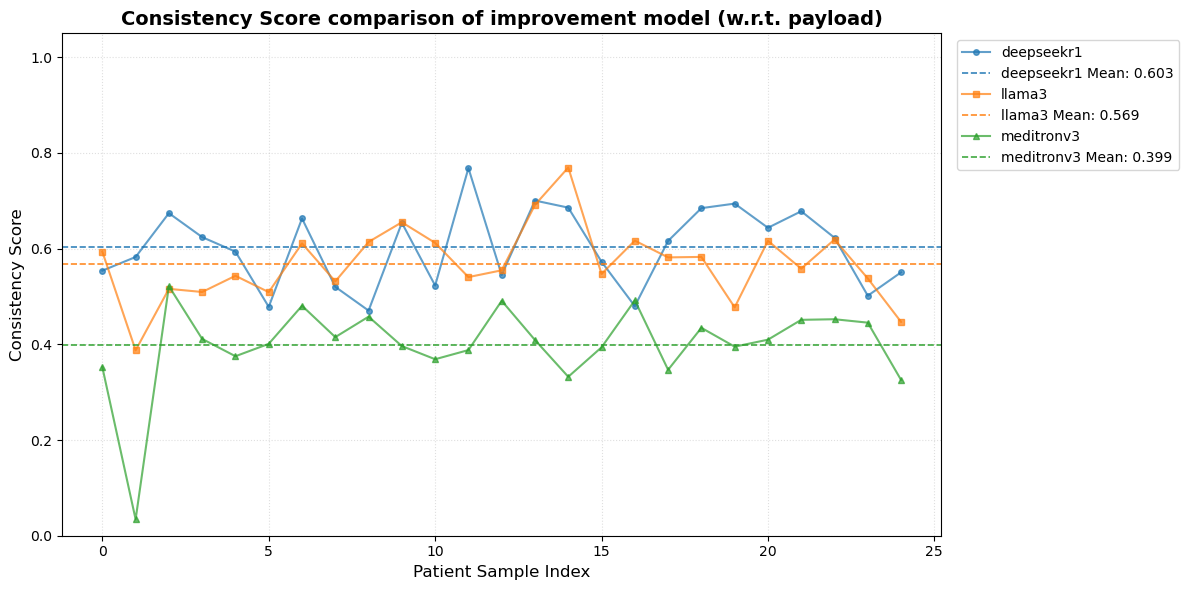

In [134]:
plot_lines(score_data['true_masks'], "Consistency Score comparison of improvement model (w.r.t. payload)","Patient Sample Index", "Consistency Score", "consistency_plot_true")

**On Pred Masks**

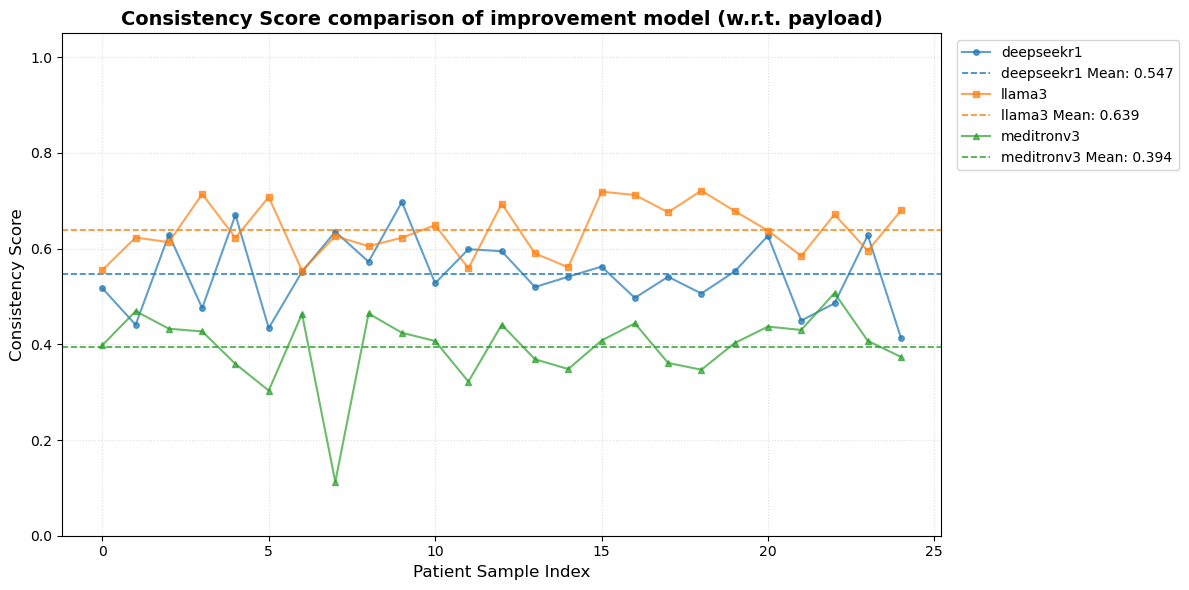

In [135]:
plot_lines(score_data['predicted_masks'],"Consistency Score comparison of improvement model (w.r.t. payload)","Patient Sample Index", "Consistency Score", "consistency_plot_pred")

**Mean Consistency Scores**

In [136]:
import numpy as np

def mean_scores(score_data):
    mean_scores = {}
    for mdl in IMP_MODELS:
        score_arr = np.array([score_data['true_masks'][mdl], score_data['predicted_masks'][mdl]])
        mean_scores[mdl] = float(np.mean(np.mean(score_arr, axis=1), axis=0))
    
    return mean_scores
imp_mean_scores = mean_scores(score_data)

In [14]:
import matplotlib.pyplot as plt

def plot_bar(results_dict, title, x_label, y_label, file_name):
    sorted_data = sorted(results_dict.items(), key=lambda x: x[1], reverse=True)
    names, scores = zip(*sorted_data)
    
    colors = plt.cm.tab10.colors
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, scores, color=colors[:len(names)], edgecolor='black', alpha=0.85)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
                 f'{yval:.4f}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')

    plt.title(f"{title}", fontsize=14, fontweight='bold')
    plt.ylabel(y_label, fontsize=12)
    plt.xlabel(x_label, fontsize=12)
    
    plt.ylim(0, max(scores) * 1.15) 
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"./outputs/evaluation/{file_name}.png")

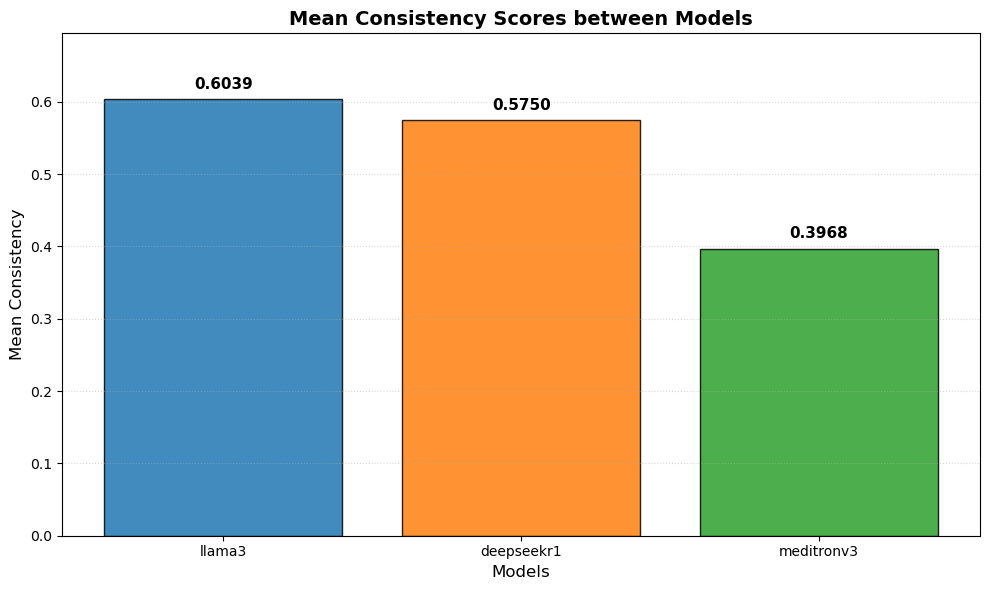

In [145]:
plot_bar(imp_mean_scores,"Mean Consistency Scores between Models", "Models","Mean Consistency", 'mean_consistency_plot')

**Models consistency difference between True Mask and Pred Mask Models Outputs**

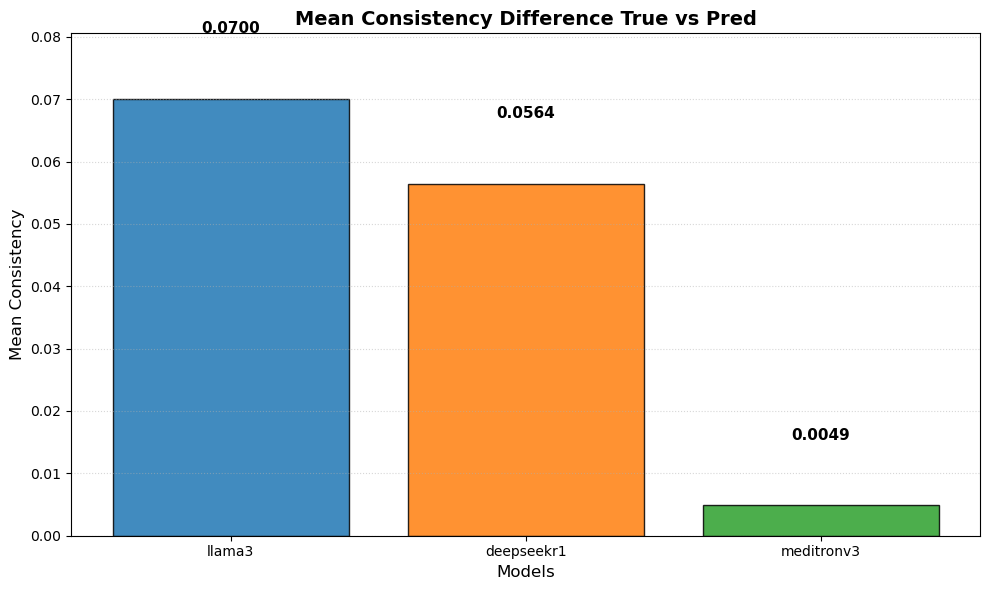

In [147]:
mean_divergence = {}
for mdl in IMP_MODELS:
    mean_divergence[mdl] = abs(np.mean(score_data['true_masks'][mdl]) - np.mean(score_data['predicted_masks'][mdl]))
plot_bar(mean_divergence, "Mean Consistency Difference True vs Pred", "Models","Mean Consistency", 'true_pred_consistency_diff_plot')

#### **Without Knowledge Graph (Ablation)**

In [79]:
evaluator = ConsistencyScorer()
score_data = {}
for mask in IMP_MASKS:
    df = pd.DataFrame()
    print (f"--------- {mask} --------\n")
    for imp_model in IMP_MODELS:
        print(f"Evaluating Consistency Score for model {imp_model}:\n")
        results = evaluator.score(f"{ABLATIONS_DIR}//{imp_model}//{mask}", f"{PAYLOAD_DIR}//{mask}")
        df[imp_model] = results
    score_data[mask] = df

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 12573.82it/s]


--------- predicted_masks --------

Evaluating Consistency Score for model deepseekr1:



Scoring consistency: 100%|██████████| 25/25 [00:24<00:00,  1.00it/s]


Evaluating Consistency Score for model llama3:



Scoring consistency: 100%|██████████| 25/25 [00:12<00:00,  1.99it/s]


...

Scoring consistency: 100%|██████████| 25/25 [00:18<00:00,  1.32it/s]


Evaluating Consistency Score for model llama3:



Scoring consistency: 100%|██████████| 25/25 [00:13<00:00,  1.83it/s]


Evaluating Consistency Score for model meditronv3:



Scoring consistency: 100%|██████████| 25/25 [00:00<00:00, 1798.80it/s]


In [82]:
score_data['true_masks'].to_csv("./outputs/evaluation/consistency_scores_true_abl.csv", index=False)
score_data['predicted_masks'].to_csv("./outputs/evaluation/consistency_scores_pred_abl.csv", index=False)

In [148]:
score_data = {}
score_data['true_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_true_abl.csv', )
score_data['predicted_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_pred_abl.csv')

<>:2: DeprecationWarning: invalid escape sequence '\e'
<>:3: DeprecationWarning: invalid escape sequence '\e'
<>:2: DeprecationWarning: invalid escape sequence '\e'
<>:3: DeprecationWarning: invalid escape sequence '\e'
C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_28076\2811138782.py:2: DeprecationWarning: invalid escape sequence '\e'
  score_data['true_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_true_abl.csv', )
C:\Users\Syed Daniyal\AppData\Local\Temp\ipykernel_28076\2811138782.py:3: DeprecationWarning: invalid escape sequence '\e'
  score_data['predicted_masks'] = pd.read_csv('outputs\evaluation\consistency_scores_pred_abl.csv')


**On True Masks**

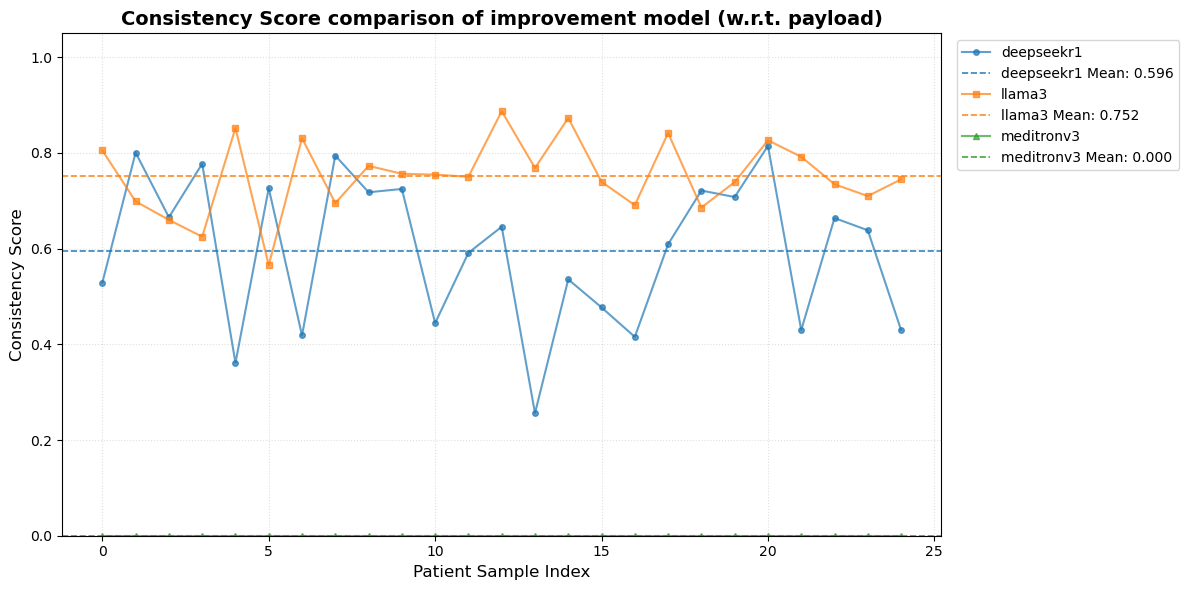

In [149]:
plot_lines(score_data['true_masks'], "Consistency Score comparison of improvement model (w.r.t. payload)","Patient Sample Index", "Consistency Score", "consistency_plot_true_abl")

**On Pred Masks**

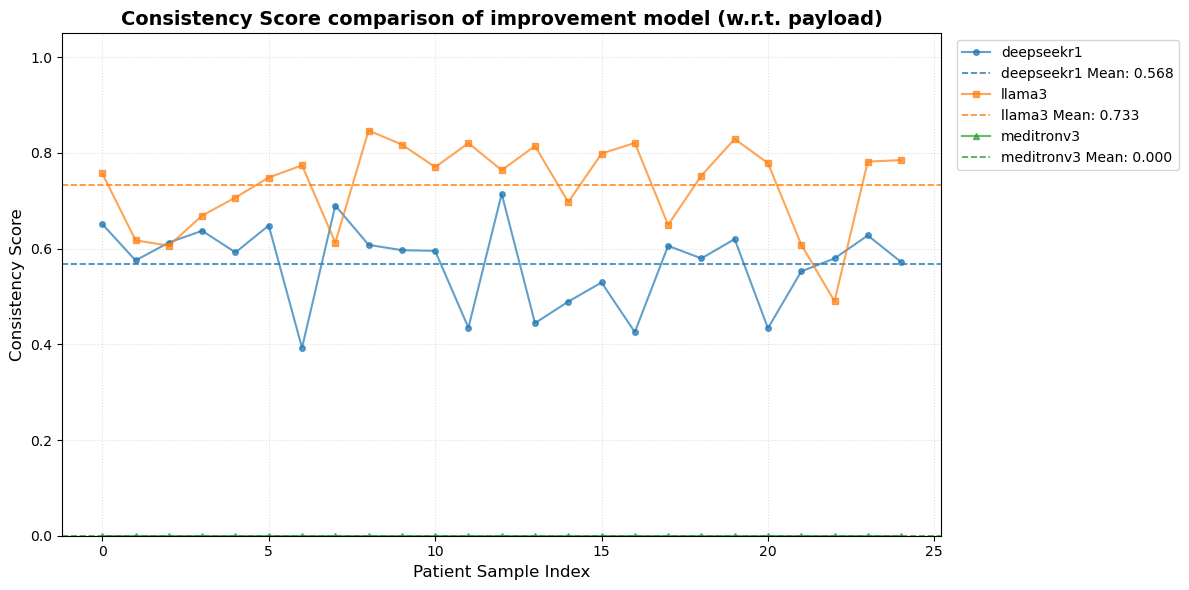

In [150]:
plot_lines(score_data['predicted_masks'], "Consistency Score comparison of improvement model (w.r.t. payload)","Patient Sample Index", "Consistency Score", "consistency_plot_pred_abl")

**Mean Consistency Scores**

In [151]:
abl_mean_scores = mean_scores(score_data)

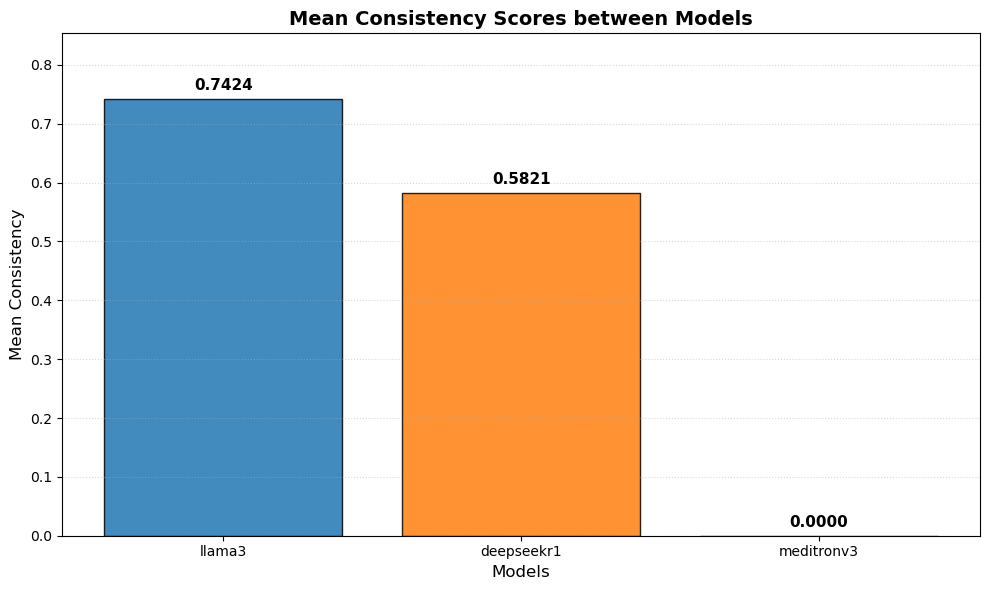

In [152]:
plot_bar(abl_mean_scores, "Mean Consistency Scores between Models", "Models","Mean Consistency", 'mean_consistency_plot_abl')

**Models mean divergence between KG and Ablation Models**

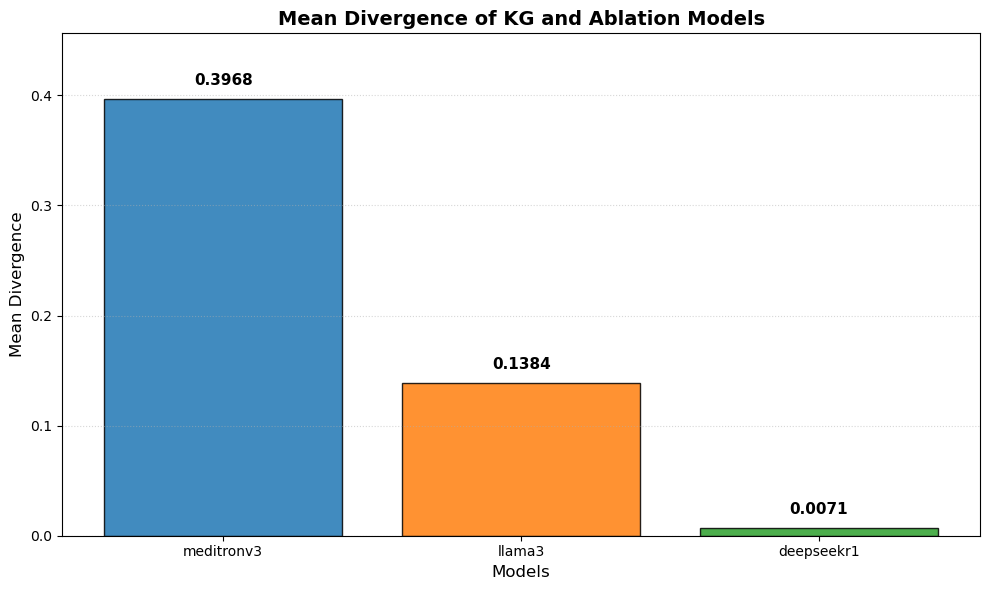

In [154]:
mean_divergence = {}
for mdl in IMP_MODELS:
    mean_divergence[mdl] = abs(imp_mean_scores[mdl] - abl_mean_scores[mdl])

plot_bar(mean_divergence, "Mean Divergence of KG and Ablation Models", "Models", "Mean Divergence", 'kg_abl_diff_plot')

#### **Green score and Hallucination evaluation for divergence of pred masks output from true mask output**

In [15]:
from bert_score import score as bert_score

class BertScorer:
    def __init__(self, model="microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"):
        self.model = model

    def score(self, ref_dir, target_dir):
        ref_files = self._sorted_files(ref_dir)
        target_files = self._sorted_files(target_dir)

        refs = [p.read_text(encoding="utf-8").strip() for p in ref_files]
        hyps = [p.read_text(encoding="utf-8").strip() for p in target_files]

        _, _, f1 = bert_score(hyps, refs, model_type=self.model, num_layers=24, verbose=False)
        return f1.tolist()

    @staticmethod
    def _sorted_files(directory):
        import re
        from pathlib import Path
        def natural_key(p):
            return [int(x) if x.isdigit() else x.lower() for x in re.split(r"(\d+)", p.stem)]
        return sorted(Path(directory).glob("*.txt"), key=natural_key)

In [125]:
divergence_data = pd.DataFrame()
for mdl in IMP_MODELS:
    print(f"Evaluating model {mdl}:")
    col = evaluate_reports(f"{IMP_DIR}//{mdl}//true_masks", f"{IMP_DIR}//{mdl}//predicted_masks")
    divergence_data[mdl] = col

Evaluating model deepseekr1:


25it [09:46, 23.45s/it]


Evaluating model llama3:


25it [09:20, 22.44s/it]


Evaluating model meditronv3:


25it [08:36, 20.66s/it]


In [127]:
divergence_data.to_csv("./outputs/evaluation/divergence_true_pred.csv",index=False)

In [17]:
divergence_data = pd.read_csv("./outputs/evaluation/divergence_true_pred.csv")

In [62]:
import ast
def get_green_scores(data, headers):
    scores = pd.DataFrame()
    for mdl in headers:
        col = data[mdl]
        scores[mdl] = [(ast.literal_eval(entry))['green_score'] for entry in list(col)]
    return scores

In [65]:
import ast
def get_hallucination_scores(data, headers):
    scores = pd.DataFrame()
    for mdl in headers:
        col = data[mdl]
        scores[mdl] = [(ast.literal_eval(entry))['hallucination_score'] for entry in list(col)]
    return scores

In [ ]:
green_scores = get_green_scores(divergence_data, IMP_MODELS)
hallucination_scores = get_hallucination_scores(divergence_data, IMP_MODELS)

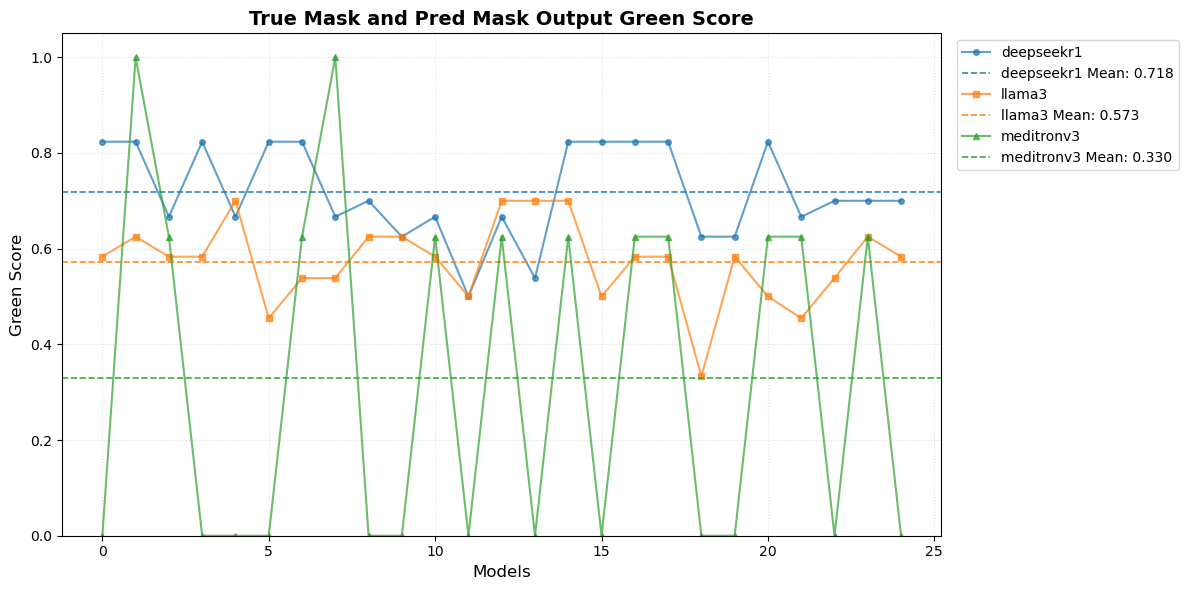

In [45]:
plot_lines(green_scores, 'True Mask and Pred Mask Output Green Score', 'Models', 'Green Score', 'green_score_true_pred')

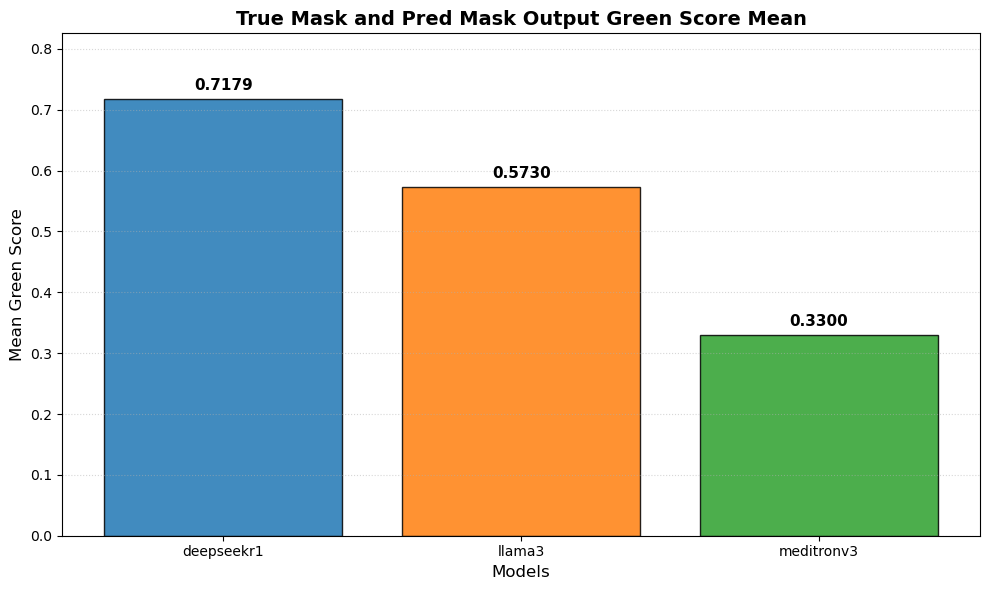

In [48]:
import numpy as np
plot_bar(np.mean(green_scores, axis=0), "True Mask and Pred Mask Output Green Score Mean", "Models","Mean Green Score","mean_green_score_true_pred")

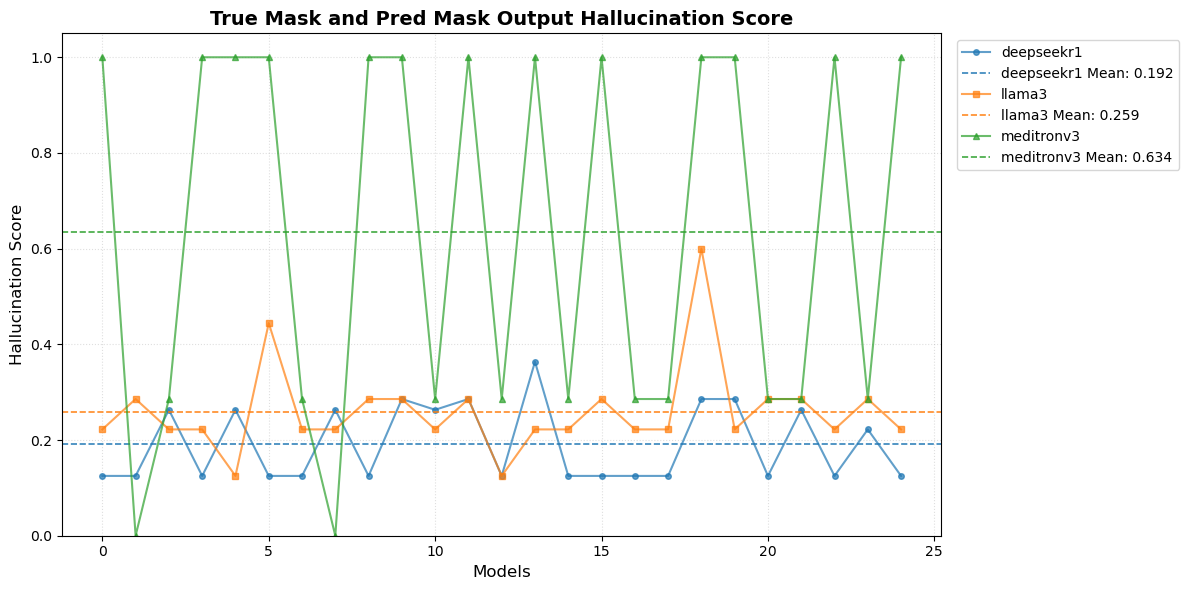

In [49]:
plot_lines(hallucination_scores, 'True Mask and Pred Mask Output Hallucination Score', 'Models', 'Hallucination Score', 'hall_score_true_pred')

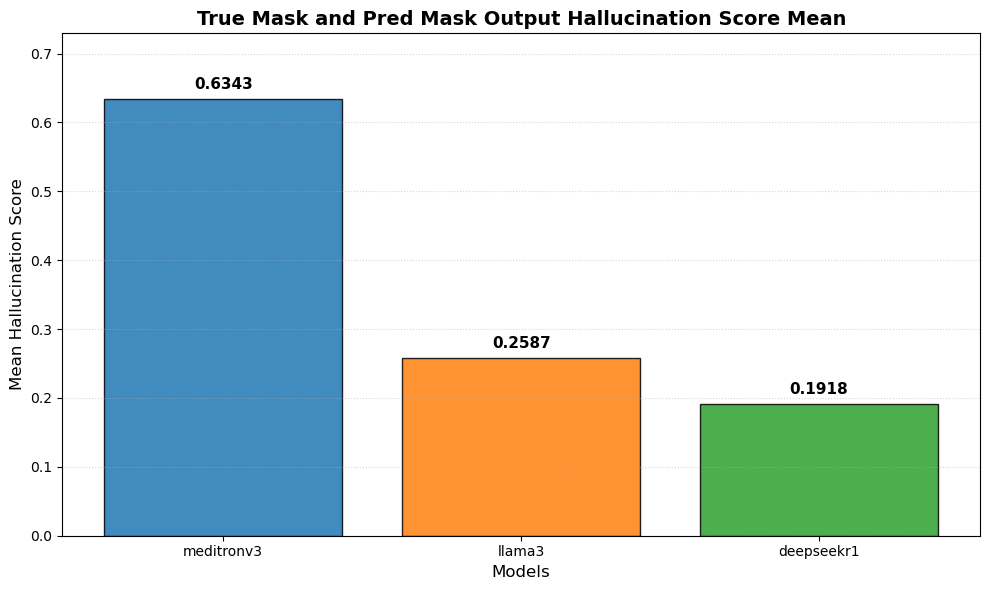

In [50]:
plot_bar(np.mean(hallucination_scores, axis=0), "True Mask and Pred Mask Output Hallucination Score Mean", "Models","Mean Hallucination Score","mean_hallucination_score_true_pred")

#### **Results:**
**llama3 showed most stability and consistency and hence will be used as reference to evaluate the baseline models**

## **Comparison of Baseline and Improvement Architecture (Green Score and Hallucinations)**

#### **True Mask Baseline vs. True Mask Improvement Model**

In [54]:
true_score_data = pd.DataFrame()
for baseline_model in BASELINE_MODELS:
    print(f"Evaluating {baseline_model} Baseline Architecture:")
    results = evaluate_reports(f"{IMP_DIR}/llama3/true_masks/", f"{BASELINE_DIR}/true_masks/{baseline_model}/")
    true_score_data[baseline_model] = results


Evaluating llava-13b Baseline Architecture:


0it [00:00, ?it/s]

25it [04:04,  9.76s/it]


Evaluating medgemma-27b Baseline Architecture:


25it [03:43,  8.92s/it]


Evaluating qwen-7b Baseline Architecture:


25it [04:11, 10.06s/it]


In [ ]:
true_score_data.to_csv("./outputs/evaluation/true_score_data_baseline_v_llama3.csv", index=False)

In [60]:
true_score_data = pd.read_csv("./outputs/evaluation/true_score_data_baseline_v_llama3.csv")

In [66]:
true_green_scores = get_green_scores(true_score_data, BASELINE_MODELS)
true_hallucination_scores = get_hallucination_scores(true_score_data, BASELINE_MODELS)

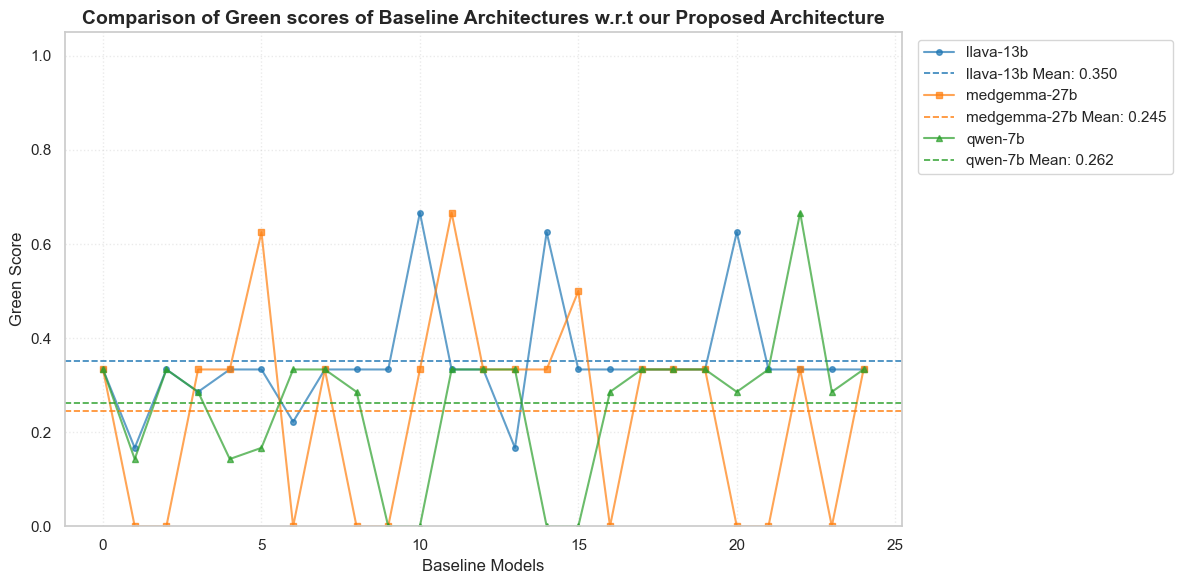

In [67]:
plot_lines(true_green_scores, "Comparison of Green scores of Baseline Architectures w.r.t our Proposed Architecture", "Baseline Models", "Green Score", "green_score_baseline")

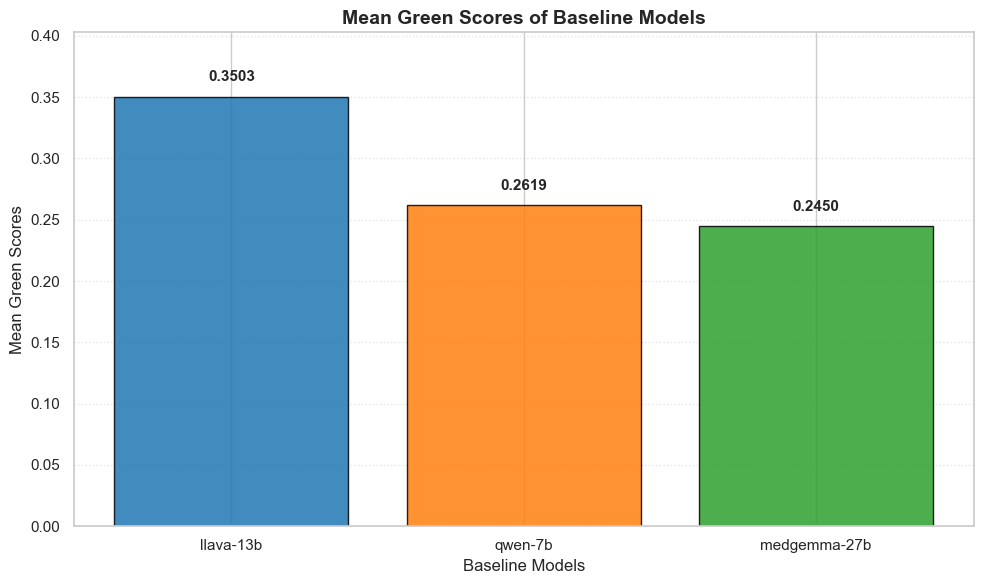

In [68]:
plot_bar(np.mean(true_green_scores, axis=0), "Mean Green Scores of Baseline Models", "Baseline Models", "Mean Green Scores", "mean_green_score_baseline")

#### **Pred Mask Baseline vs. Pred Mask Improvement Model**

In [57]:
pred_score_data = pd.DataFrame()
for baseline_model in BASELINE_MODELS:
    print(f"Evaluating {baseline_model} Baseline Architecture:")
    results = evaluate_reports(f"{IMP_DIR}/llama3/predicted_masks/", f"{BASELINE_DIR}/pred_masks/{baseline_model}/")
    pred_score_data[baseline_model] = results


Evaluating llava-13b Baseline Architecture:


25it [04:12, 10.10s/it]


Evaluating medgemma-27b Baseline Architecture:


25it [04:03,  9.75s/it]


Evaluating qwen-7b Baseline Architecture:


25it [04:25, 10.64s/it]


In [58]:
pred_score_data.to_csv("./outputs/evaluation/pred_score_data_baseline_v_llama3.csv", index=False)

In [ ]:
pred_score_data = pd.read_csv("./outputs/evaluation/pred_score_data_baseline_v_llama3.csv")

In [69]:
pred_green_scores = get_green_scores(pred_score_data, BASELINE_MODELS)
pred_hallucination_scores = get_hallucination_scores(pred_score_data, BASELINE_MODELS)

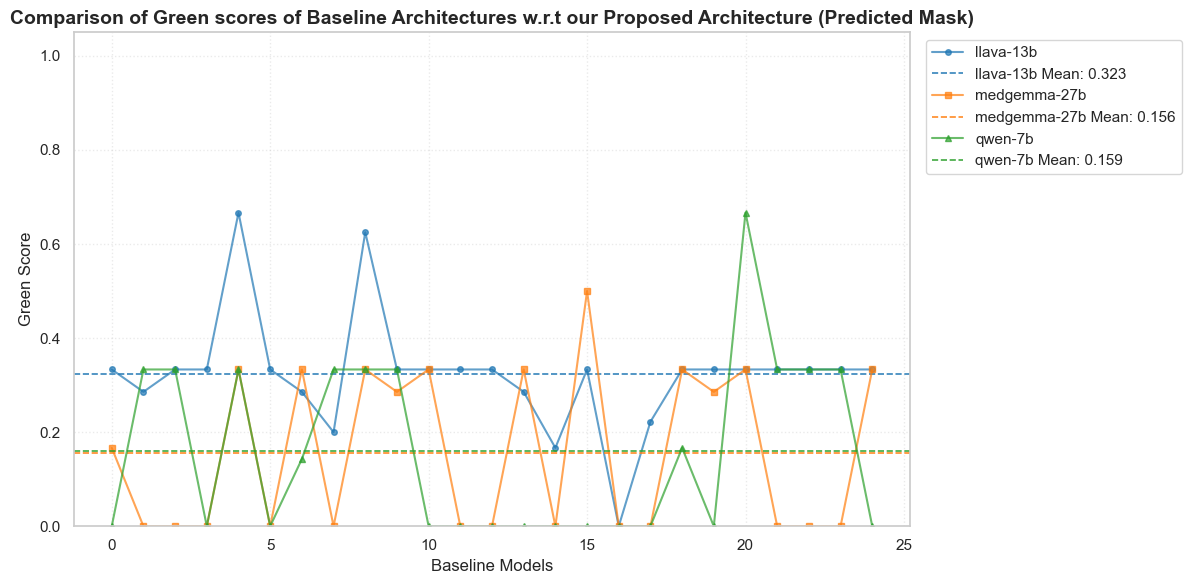

In [70]:
plot_lines(pred_green_scores, "Comparison of Green scores of Baseline Architectures w.r.t our Proposed Architecture (Predicted Mask)", "Baseline Models", "Green Score", "green_score_baseline_pred")

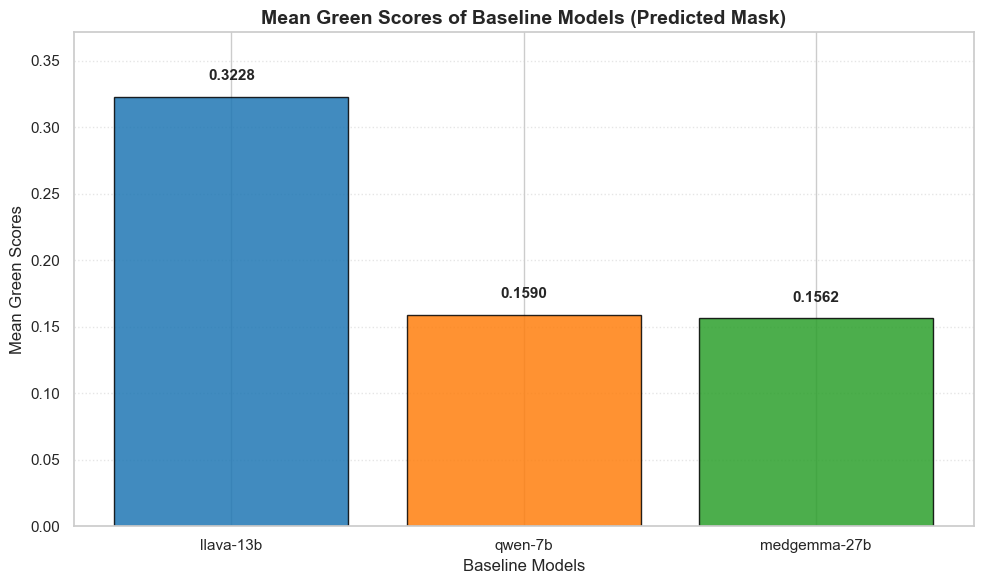

In [71]:
plot_bar(np.mean(pred_green_scores, axis=0), "Mean Green Scores of Baseline Models (Predicted Mask)", "Baseline Models", "Mean Green Scores", "mean_green_score_baseline_pred")

#### **Further results are included in the paper**